# Trabajo Práctico Final - Aprendizaje de Máquina I (CEIA - FIUBA)

## Parte II: poniendo a prueba nuestras propias conclusiones

**Integrantes:** Nelson Martín Villagra y Víctor Hugo Astorga

**Fecha:** octubre de 2026

## Lo que pasó en la Parte I

En la Parte I (notebook `tp_final.ipynb`) quisimos detectar la fuga interna de la bomba de un banco hidráulico (sin fuga, fuga leve o fuga severa) a partir de los 17 sensores de un ciclo de 60 segundos. En resumen:

- Descubrimos que el experimento se hizo en **tres etapas con el aceite a distinta temperatura** (55, 45 y 36 °C), y por eso separamos entrenamiento y test cortando por tiempo **dentro de cada etapa**.
- El baseline (dos umbrales sobre la eficiencia promedio, `SE_mean`) sacó un F1 macro de 0,77.
- El mejor modelo fue un **árbol de decisión de dos niveles** que pregunta por los percentiles altos de `SE`, con F1 macro de 0,99 en test.
- Y terminamos con una observación incómoda: la misma regla de umbrales, pero sobre `SE_q90`, llegaba a 0,99. O sea, casi todo el trabajo lo hacía una sola variable.

## La crítica

Le pedimos a alguien de afuera que revisara el trabajo sin piedad. Las objeciones más fuertes fueron estas:

1. **"SE no es un sensor, es un cálculo."** El factor de eficiencia `SE` lo calcula el propio sistema a partir de otras mediciones. Según la crítica, el modelo no aprendió a detectar la fuga, sólo aprendió a leer un indicador que los ingenieros del banco ya habían armado.
2. **"Dividir por etapa es hacer trampa."** En una planta real la máquina puede trabajar a una temperatura que no aparece en el entrenamiento (por ejemplo, porque cambió la estación del año). Al poner las tres temperaturas en entrenamiento y en test, la Parte I esconde si los modelos sirven en ese caso.
3. **"No miraron las curvas ROC"**, que en la materia usamos para evaluar clasificadores más allá de un único umbral.
4. **"Resumir el ciclo entero con un número tira información, y faltó el análisis de frecuencias."**

Algunas nos parecieron injustas y otras no, pero en lugar de discutirlas decidimos ponerlas a prueba. Esta Parte II tiene dos experimentos:

- **Experimento 1:** volver a hacer todo **sin los sensores calculados** (`SE`, `CE` y `CP`), sólo con sensores físicos. Acá respondemos también las críticas 3 y 4.
- **Experimento 2:** evaluar los modelos con **una temperatura que no vieron nunca** al entrenar (crítica 2).

## Preparación

Usamos el mismo dataset y la misma forma de extraer features que en la Parte I (los 12 estadísticos por sensor y por ciclo). Para correr este notebook, el dataset tiene que estar en la carpeta `data/` (ver el README).

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             roc_curve, roc_auc_score)
from sklearn.base import clone
from xgboost import XGBClassifier

SEMILLA = 42
DATA_DIR = Path("data")

plt.rcParams.update({
    "figure.dpi": 90, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e6", "axes.axisbelow": True,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": "#444444", "xtick.color": "#555555", "ytick.color": "#555555",
})
COLOR_BOMBA = {0: "#2a78d6", 1: "#eda100", 2: "#e34948"}
GRIS = "#9a9a9a"
VIOLETA = "#4a3aa7"
NOMBRES_BOMBA = {0: "sin fuga", 1: "fuga leve", 2: "fuga severa"}
CLASES = [0, 1, 2]

In [2]:
FISICOS = ["PS1", "PS2", "PS3", "PS4", "PS5", "PS6", "EPS1", "FS1", "FS2",
           "TS1", "TS2", "TS3", "TS4", "VS1"]
CALCULADOS = ["CE", "CP", "SE"]

if not (DATA_DIR / "profile.txt").exists():
    raise FileNotFoundError(
        "No se encontró data/profile.txt. Descargar el dataset de "
        "https://www.kaggle.com/datasets/jjacostupa/condition-monitoring-of-hydraulic-systems "
        "y descomprimirlo en la carpeta data/ al lado del notebook."
    )

crudo = {s: pd.read_csv(DATA_DIR / f"{s}.txt", sep="\t", header=None).to_numpy(np.float32)
         for s in FISICOS + CALCULADOS}
perfil = pd.read_csv(DATA_DIR / "profile.txt", sep="\t", header=None,
                     names=["enfriador", "valvula", "bomba", "acumulador", "estable"])
y = perfil["bomba"].to_numpy()
etapa = perfil["enfriador"].to_numpy()
NOMBRE_ETAPA = {3: "etapa 1 (~55 °C)", 20: "etapa 2 (~45 °C)", 100: "etapa 3 (~36 °C)"}


def extraer_features(datos, nombre):
    # los mismos 12 estadísticos que en la Parte I
    f = {
        f"{nombre}_mean": datos.mean(axis=1),
        f"{nombre}_std": datos.std(axis=1),
        f"{nombre}_min": datos.min(axis=1),
        f"{nombre}_max": datos.max(axis=1),
    }
    for q in [10, 25, 50, 75, 90]:
        f[f"{nombre}_q{q}"] = np.percentile(datos, q, axis=1)
    f[f"{nombre}_range"] = f[f"{nombre}_max"] - f[f"{nombre}_min"]
    f[f"{nombre}_rms"] = np.sqrt((datos ** 2).mean(axis=1))
    f[f"{nombre}_slope"] = (datos[:, -1] - datos[:, 0]) / datos.shape[1]
    return pd.DataFrame(f)


X_todos = pd.concat([extraer_features(crudo[s], s) for s in FISICOS + CALCULADOS], axis=1)
X_fis = X_todos[[c for c in X_todos.columns if c.split("_")[0] in FISICOS]]
print("Features con todos los sensores:", X_todos.shape)
print("Features sólo con sensores físicos:", X_fis.shape)

Features con todos los sensores: (2205, 204)
Features sólo con sensores físicos: (2205, 168)


In [3]:
# la misma división que en la Parte I: en cada etapa, 75% entrenamiento y 25% test
es_test = np.zeros(len(perfil), dtype=bool)
for valor in [3, 20, 100]:
    idx = np.flatnonzero(etapa == valor)
    es_test[idx[int(len(idx) * 0.75):]] = True

Xf_train, Xf_test = X_fis[~es_test], X_fis[es_test]
y_train, y_test = y[~es_test], y[es_test]
cv = KFold(n_splits=5, shuffle=False)


def evaluar(nombre, y_real, y_pred):
    cm = confusion_matrix(y_real, y_pred, labels=CLASES)
    return {
        "modelo": nombre,
        "F1 macro test": f1_score(y_real, y_pred, average="macro"),
        "accuracy test": accuracy_score(y_real, y_pred),
        "% falsas alarmas": 100 * cm[0, 1:].sum() / cm[0].sum(),
        "% fugas no detectadas": 100 * cm[1:, 0].sum() / cm[1:].sum(),
    }

## Experimento 1: sin sensores calculados

Sacamos `SE`, `CE` y `CP` y nos quedamos con los 14 sensores que miden algo físico de verdad: presiones, potencia del motor, caudales, temperaturas y vibración. Son 168 features (14 × 12).

### 1.1 El nuevo baseline

Sin `SE`, ¿qué regla simple podemos armar? En la Parte I vimos que el caudal `FS1` baja con la fuga (el aceite que se escapa no llega al circuito), así que lo usamos con el mismo método de dos umbrales. Usamos la mediana del caudal en el ciclo (`FS1_q50`) en lugar del promedio, porque en la Parte I aprendimos que el promedio se ve arrastrado por los tramos en que la bomba está arrancando.

In [4]:
mediana = pd.Series(Xf_train["FS1_q50"].to_numpy()).groupby(y_train).median()
umbral_alto = (mediana[0] + mediana[1]) / 2
umbral_bajo = (mediana[1] + mediana[2]) / 2
print("Mediana de FS1_q50 por clase (entrenamiento):")
print(mediana.rename(NOMBRES_BOMBA).round(3))


def regla_caudal(df):
    q = df["FS1_q50"].to_numpy()
    return np.where(q > umbral_alto, 0, np.where(q > umbral_bajo, 1, 2))


resultados = [{**evaluar("Baseline: umbrales sobre FS1", y_test, regla_caudal(Xf_test)),
               "F1 macro CV": f1_score(y_train, regla_caudal(Xf_train), average="macro")}]
pd.DataFrame(resultados).set_index("modelo").round(3)

Mediana de FS1_q50 por clase (entrenamiento):
sin fuga       7.779
fuga leve      7.561
fuga severa    7.439
dtype: float32


,F1 macro test,accuracy test,% falsas alarmas,% fugas no detectadas,F1 macro CV
modelo,,,,,
Baseline: umbrales sobre FS1,0.839,0.87,7.719,0.0,0.884


La regla del caudal saca alrededor de 0,84, un poco más que el baseline de la Parte I. O sea que el caudal solo ya separa bastante, pero queda margen para mejorar.

### 1.2 Los modelos

Entrenamos las mismas familias que en la Parte I, con búsqueda de hiperparámetros por validación cruzada sobre el entrenamiento (`GridSearchCV` con `KFold(shuffle=False)`, igual que antes). Agregamos una **SVM con kernel lineal**: es la misma idea de la SVM que vimos en clase (buscar la frontera con mayor margen), pero la frontera es un plano en lugar de una curva. La incluimos porque, si lo que hace falta es combinar varios sensores con distintos pesos, un modelo lineal puede ser suficiente y es más fácil de interpretar.

In [5]:
candidatos = {
    "KNN": (Pipeline([("escalado", StandardScaler()), ("modelo", KNeighborsClassifier())]),
            {"modelo__n_neighbors": [5, 11, 21, 31], "modelo__weights": ["uniform", "distance"],
             "modelo__p": [1, 2]}),
    "SVM (RBF)": (Pipeline([("escalado", StandardScaler()),
                            ("modelo", SVC(class_weight="balanced"))]),
                  {"modelo__C": [0.1, 1, 10, 100], "modelo__gamma": ["scale", 0.001, 0.01]}),
    "SVM (lineal)": (Pipeline([("escalado", StandardScaler()),
                               ("modelo", SVC(kernel="linear", class_weight="balanced"))]),
                     {"modelo__C": [0.001, 0.01, 0.1, 1]}),
    "Árbol de decisión": (DecisionTreeClassifier(class_weight="balanced", random_state=SEMILLA),
                          {"max_depth": [2, 3, 4, 6, None], "min_samples_leaf": [1, 5, 20]}),
    "Random Forest": (RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                             random_state=SEMILLA, n_jobs=-1),
                      {"max_features": ["sqrt", 0.3], "min_samples_leaf": [1, 5]}),
    "XGBoost": (XGBClassifier(random_state=SEMILLA, n_jobs=-1),
                {"n_estimators": [100, 300], "max_depth": [2, 4], "learning_rate": [0.05, 0.2]}),
}

modelos = {}
for nombre, (modelo, grilla) in candidatos.items():
    inicio = time.time()
    busqueda = GridSearchCV(modelo, grilla, cv=cv, scoring="f1_macro", n_jobs=-1)
    busqueda.fit(Xf_train, y_train)
    modelos[nombre] = busqueda.best_estimator_
    resultados.append({**evaluar(nombre, y_test, busqueda.predict(Xf_test)),
                       "F1 macro CV": busqueda.best_score_})
    print(f"{nombre:18s} CV = {busqueda.best_score_:.3f}  {busqueda.best_params_}  "
          f"({time.time() - inicio:.0f} s)")

tabla = (pd.DataFrame(resultados).set_index("modelo")
         [["F1 macro CV", "F1 macro test", "accuracy test",
           "% falsas alarmas", "% fugas no detectadas"]])
tabla.round(3)

KNN                CV = 0.703  {'modelo__n_neighbors': 21, 'modelo__p': 1, 'modelo__weights': 'uniform'}  (3 s)


SVM (RBF)          CV = 0.848  {'modelo__C': 100, 'modelo__gamma': 0.001}  (1 s)


SVM (lineal)       CV = 0.888  {'modelo__C': 0.01}  (0 s)


Árbol de decisión  CV = 0.752  {'max_depth': 4, 'min_samples_leaf': 20}  (1 s)


Random Forest      CV = 0.786  {'max_features': 0.3, 'min_samples_leaf': 5}  (10 s)


XGBoost            CV = 0.750  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}  (11 s)


,F1 macro CV,F1 macro test,accuracy test,% falsas alarmas,% fugas no detectadas
modelo,,,,,
Baseline: umbrales sobre FS1,0.884,0.839,0.870,7.719,0.000
KNN,0.703,0.930,0.938,4.561,2.622
SVM (RBF),0.848,0.995,0.996,0.000,0.000
SVM (lineal),0.888,0.991,0.993,0.351,0.000
Árbol de decisión,0.752,0.908,0.926,4.561,0.000
Random Forest,0.786,0.903,0.922,4.561,0.000
XGBoost,0.750,0.897,0.928,0.702,0.000


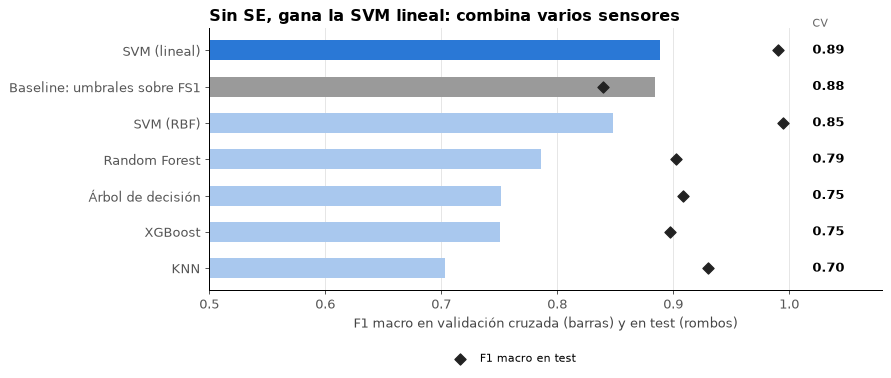

In [6]:
orden = tabla.sort_values("F1 macro CV")
fig, ax = plt.subplots(figsize=(10, 4.4))
pos = np.arange(len(orden))
es_base = orden.index.str.startswith("Baseline")
es_mejor = orden.index == orden["F1 macro CV"].idxmax()
colores = np.where(es_base, GRIS, np.where(es_mejor, "#2a78d6", "#a9c8ee"))
ax.barh(pos, orden["F1 macro CV"], height=0.55, color=colores)
ax.scatter(orden["F1 macro test"], pos, color="#222222", marker="D", s=40, zorder=3,
           label="F1 macro en test")
for i, v in enumerate(orden["F1 macro CV"]):
    ax.text(1.02, i, f"{v:.2f}", va="center", fontsize=10, fontweight="bold")
ax.text(1.02, len(orden) - 0.35, "CV", fontsize=9, color="#666666")
ax.set_yticks(pos, orden.index)
ax.set_xlim(0.5, 1.08)
ax.grid(axis="y", visible=False)
ax.set_xlabel("F1 macro en validación cruzada (barras) y en test (rombos)")
ax.legend(loc="upper center", bbox_to_anchor=(0.45, -0.2), frameon=False, fontsize=9)
ax.set_title("Sin SE, gana la SVM lineal: combina varios sensores")
plt.tight_layout()
plt.show()

Acá el panorama cambia respecto de la Parte I:

- **El árbol de decisión ya no es el mejor.** Sin `SE` no hay una variable que separe todo con pocas preguntas: el árbol queda por debajo del baseline en validación cruzada y apenas por encima en test.
- **La SVM lineal es la mejor en validación cruzada** y en test prácticamente no se equivoca. La SVM con kernel RBF también anda muy bien en test, pero en validación cruzada queda más abajo.
- Random Forest y XGBoost quedan en un punto intermedio.

(La barra gris del baseline es el F1 de la regla sobre todo el entrenamiento, porque la regla no tiene hiperparámetros que validar. Por eso no es exactamente comparable con las demás barras.)

Es decir, cuando sacamos el atajo, **los modelos sí marcan una diferencia frente a la regla simple**: las dos SVM pasan de 0,84 a más de 0,99 en test. Lo que no puede hacer una regla de un solo sensor lo hace un modelo que combina varios.

### 1.3 ¿Qué sensores usa la SVM lineal?

Para ver en qué se apoya el modelo usamos la **importancia por permutación**: se desordena al azar una feature en el test y se mide cuánto empeora el F1. Si empeora mucho, el modelo dependía de esa feature. Sumamos la importancia de las 12 features de cada sensor.

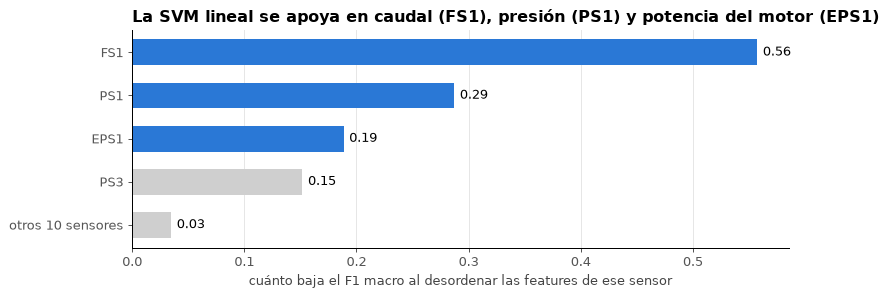

Las 6 features más importantes:
FS1_q90     0.408
PS1_q90     0.088
PS1_max     0.073
EPS1_q90    0.067
FS1_rms     0.046
PS1_q25     0.039
dtype: float64


In [7]:
elegido = modelos["SVM (lineal)"]
perm = permutation_importance(elegido, Xf_test, y_test, scoring="f1_macro",
                              n_repeats=10, random_state=SEMILLA, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_fis.columns)
por_sensor = imp.groupby(lambda c: c.split("_")[0]).sum().clip(lower=0).sort_values(ascending=False)
resto = por_sensor.iloc[4:]
graf = pd.concat([por_sensor.iloc[:4], pd.Series({f"otros {len(resto)} sensores": resto.sum()})])[::-1]

fig, ax = plt.subplots(figsize=(9, 3.4))
colores = ["#2a78d6" if s in ("FS1", "PS1", "EPS1") else "#cfcfcf" for s in graf.index]
ax.barh(graf.index, graf.values, color=colores, height=0.6)
for i, v in enumerate(graf.values):
    ax.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=10)
ax.grid(axis="y", visible=False)
ax.set_xlabel("cuánto baja el F1 macro al desordenar las features de ese sensor")
ax.set_title("La SVM lineal se apoya en caudal (FS1), presión (PS1) y potencia del motor (EPS1)")
plt.tight_layout()
plt.show()

print("Las 6 features más importantes:")
print(imp.sort_values(ascending=False).head(6).round(3))

Los tres sensores en los que más se apoya el modelo son el **caudal** que entrega la bomba (`FS1`), la **presión** a su salida (`PS1`) y la **potencia eléctrica** que consume el motor (`EPS1`). Esto tiene una explicación física que nos gustó: la potencia hidráulica que entrega una bomba es presión × caudal, y su eficiencia es esa potencia dividida por la potencia eléctrica que consume. Son exactamente los ingredientes de una eficiencia. Sin que se lo dijéramos, el modelo armó a partir de los sensores físicos algo parecido a lo que `SE` ya traía calculado.

Sobre la crítica 1, nuestra conclusión es que **tenía razón en que `SE` era un atajo, pero no en que el resultado dependiera de él**. Sin `SE` también se puede detectar la fuga, sólo que ahí sí hace falta un modelo que combine varios sensores.

### 1.4 Curvas ROC

La crítica 3 decía que sólo miramos el modelo con un umbral fijo. Una **curva ROC** muestra qué pasa con todos los umbrales posibles: en el eje x la tasa de falsos positivos y en el eje y la tasa de verdaderos positivos. Cuanto más pegada a la esquina de arriba a la izquierda, mejor; el área bajo la curva (AUC) resume eso en un número entre 0,5 (azar) y 1 (perfecto). Como tenemos tres clases, hacemos una curva por clase contra las otras dos (*one-vs-rest*), usando el puntaje que la SVM le da a cada clase.

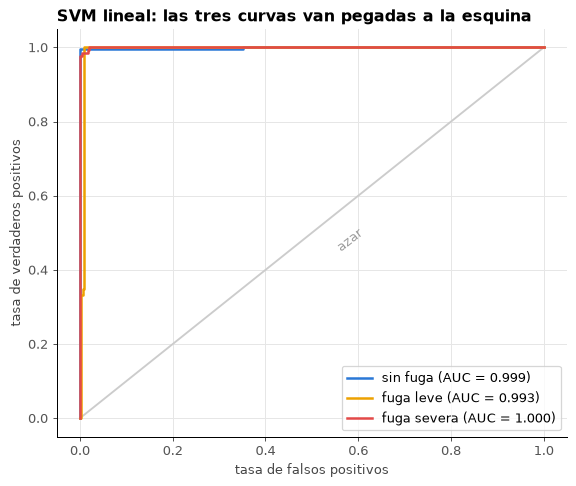

In [8]:
puntajes = elegido.decision_function(Xf_test)
y_bin = label_binarize(y_test, classes=CLASES)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot([0, 1], [0, 1], color="#cccccc", lw=1.5)
ax.text(0.55, 0.45, "azar", color=GRIS, rotation=38)
for c in CLASES:
    fpr, tpr, _ = roc_curve(y_bin[:, c], puntajes[:, c])
    auc = roc_auc_score(y_bin[:, c], puntajes[:, c])
    ax.plot(fpr, tpr, color=COLOR_BOMBA[c], lw=2, label=f"{NOMBRES_BOMBA[c]} (AUC = {auc:.3f})")
ax.set_xlabel("tasa de falsos positivos")
ax.set_ylabel("tasa de verdaderos positivos")
ax.legend(loc="lower right")
ax.set_title("SVM lineal: las tres curvas van pegadas a la esquina")
plt.tight_layout()
plt.show()

Las tres clases tienen un AUC prácticamente de 1. Esto quiere decir que el buen resultado no depende de haber tenido suerte con el umbral: para casi cualquier umbral el modelo ordena bien los ciclos.

### 1.5 ¿Ayuda partir el ciclo en tramos?

La crítica 4 decía que resumir los 60 segundos con un solo número mezcla tramos muy distintos del ciclo. En la Parte I vimos que el ciclo tiene escalones de carga cada 10 segundos, así que probamos calcular la media y el desvío de cada sensor **en cada uno de los 6 tramos de 10 segundos**, y agregarlos a las features que ya teníamos.

In [9]:
def features_por_tramo(datos, nombre, tramos=6):
    n = datos.shape[1] // tramos
    f = {}
    for k in range(tramos):
        seg = datos[:, k * n:(k + 1) * n]
        f[f"{nombre}_t{k}_mean"] = seg.mean(axis=1)
        f[f"{nombre}_t{k}_std"] = seg.std(axis=1)
    return pd.DataFrame(f)


X_tramos = pd.concat([X_fis] + [features_por_tramo(crudo[s], s) for s in FISICOS], axis=1)
filas = []
for nombre in ["SVM (lineal)", "Random Forest"]:
    for etiqueta, XX in [("ciclo completo (168 features)", X_fis),
                         (f"ciclo completo + tramos ({X_tramos.shape[1]} features)", X_tramos)]:
        busqueda = GridSearchCV(clone(candidatos[nombre][0]), candidatos[nombre][1], cv=cv,
                                scoring="f1_macro", n_jobs=-1).fit(XX[~es_test], y_train)
        filas.append({"modelo": nombre, "features": etiqueta, "F1 macro CV": busqueda.best_score_,
                      "F1 macro test": f1_score(y_test, busqueda.predict(XX[es_test]), average="macro")})
pd.DataFrame(filas).set_index(["modelo", "features"]).round(3)

F1 macro CV  \
modelo        features                                              
SVM (lineal)  ciclo completo (168 features)                 0.888   
              ciclo completo + tramos (336 features)        0.908   
Random Forest ciclo completo (168 features)                 0.786   
              ciclo completo + tramos (336 features)        0.767   

                                                      F1 macro test  
modelo        features                                               
SVM (lineal)  ciclo completo (168 features)                   0.991  
              ciclo completo + tramos (336 features)          0.995  
Random Forest ciclo completo (168 features)                   0.903  
              ciclo completo + tramos (336 features)          0.908

Agregar los tramos mejora un poco la SVM lineal (de 0,89 a 0,91 en validación cruzada) y no cambia casi nada en el Random Forest. Es una mejora chica para duplicar la cantidad de features. Nuestra interpretación es que, para la fuga de la bomba, la diferencia está en el **nivel** de caudal, presión y potencia durante todo el tramo de trabajo (lo vimos en las curvas de la Parte I: las líneas van paralelas), y eso ya lo capturan bien los percentiles del ciclo completo. Partir el ciclo en tramos sería mucho más útil para la válvula, donde lo importante es *en qué momento* cambia la presión.

Sobre el **análisis de frecuencias**: lo pensamos y no lo hicimos, por una razón de los datos. Una bomba de pistones como la del banco, girando a unas 1500 vueltas por minuto con 7 a 9 pistones, genera pulsos de presión de unos 175 a 225 por segundo. Los sensores de presión miden 100 veces por segundo, y con esa frecuencia de muestreo sólo se pueden ver oscilaciones de hasta 50 por segundo (la mitad, lo que se conoce como límite de Nyquist). El sensor de vibración mide una vez por segundo, así que tampoco sirve para esto. Con estos datos un análisis de Fourier no puede ver la pulsación de la bomba.

## Experimento 2: una temperatura que el modelo nunca vio

Esta era la crítica que más nos preocupaba. En la Parte I separamos entrenamiento y test dentro de cada etapa, así que el modelo siempre había visto ciclos con la misma temperatura que los del test. ¿Qué pasa si no es así?

La prueba es la siguiente: **entrenamos con dos etapas y evaluamos con la tercera**, y lo repetimos tres veces, una por cada etapa que dejamos afuera. Es una validación cruzada en la que cada "pliegue" es una etapa entera (en scikit-learn se puede hacer con `GroupKFold` usando la etapa como grupo; acá lo escribimos a mano para que se vea qué hace). Usamos cada modelo con los hiperparámetros que encontramos en el experimento 1, y lo probamos con y sin los sensores calculados.

In [10]:
def f1_por_etapa(modelo, XX):
    resultado = {}
    for valor, nombre in NOMBRE_ETAPA.items():
        afuera = etapa == valor
        m = clone(modelo).fit(XX[~afuera], y[~afuera])
        resultado[nombre] = f1_score(y[afuera], m.predict(XX[afuera]), average="macro")
    return resultado


nombres_modelos = ["KNN", "SVM (RBF)", "SVM (lineal)", "Árbol de decisión", "Random Forest", "XGBoost"]
sin_calc = pd.DataFrame({n: f1_por_etapa(modelos[n], X_fis) for n in nombres_modelos}).T
con_calc = pd.DataFrame({n: f1_por_etapa(modelos[n], X_todos) for n in nombres_modelos}).T
sin_calc

,etapa 1 (~55 °C),etapa 2 (~45 °C),etapa 3 (~36 °C)
KNN,0.237089,0.237089,0.778470
SVM (RBF),0.421742,1.000000,0.232190
SVM (lineal),0.576959,1.000000,0.691335
Árbol de decisión,0.546540,0.869314,0.294025
Random Forest,0.533896,0.857892,0.498467
XGBoost,0.504568,0.997967,0.278114


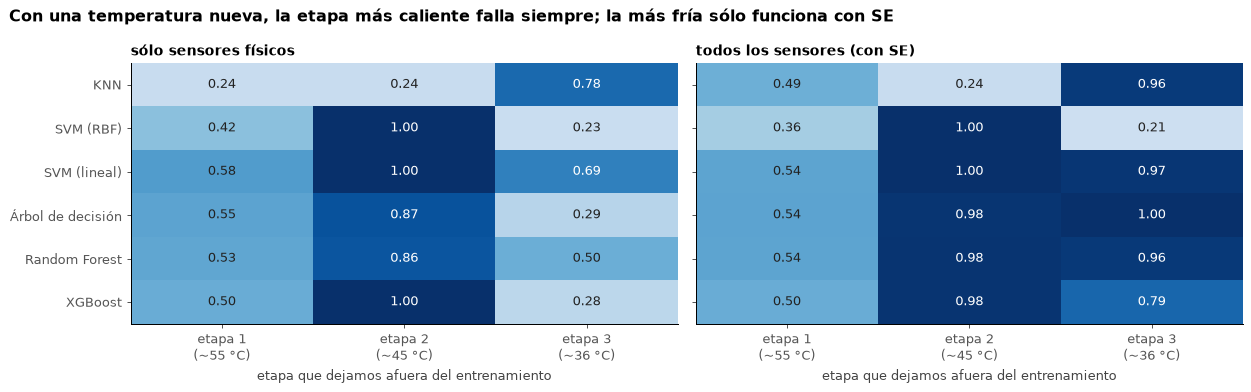

Promedio de las tres etapas:


,sin sensores calculados,con todos los sensores
KNN,0.42,0.56
SVM (RBF),0.55,0.52
SVM (lineal),0.76,0.84
Árbol de decisión,0.57,0.84
Random Forest,0.63,0.83
XGBoost,0.59,0.76


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
for ax, (titulo, tabla_t) in zip(axes, [("sólo sensores físicos", sin_calc),
                                        ("todos los sensores (con SE)", con_calc)]):
    im = ax.imshow(tabla_t.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
    for i in range(tabla_t.shape[0]):
        for j in range(tabla_t.shape[1]):
            v = tabla_t.iloc[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v > 0.6 else "#222222", fontsize=10)
    ax.set_xticks(range(3), [c.replace(" (", "\n(") for c in tabla_t.columns])
    ax.set_yticks(range(len(tabla_t)), tabla_t.index)
    ax.grid(False)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("etapa que dejamos afuera del entrenamiento")
fig.suptitle("Con una temperatura nueva, la etapa más caliente falla siempre; la más fría sólo funciona con SE",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Promedio de las tres etapas:")
pd.DataFrame({"sin sensores calculados": sin_calc.mean(axis=1),
              "con todos los sensores": con_calc.mean(axis=1)}).round(2)

El resultado depende mucho de qué etapa dejamos afuera:

- **Etapa 2 (45 °C):** casi todos los modelos funcionan bien. Su temperatura queda entre las otras dos, así que el modelo sólo tiene que *interpolar*.
- **Etapa 3 (36 °C, la más fría):** sin `SE` la mayoría falla; con `SE` casi todos funcionan. Acá aparece algo que no esperábamos: **`SE`, justamente por ser una eficiencia calculada, ya compensa buena parte del efecto de la temperatura**, y eso le permite al modelo *extrapolar* hacia temperaturas más bajas.
- **Etapa 1 (55 °C, la más caliente):** todos fallan, con o sin `SE`, con F1 entre 0,24 y 0,58. Es la etapa con los ciclos raros que vimos en la Parte I (la eficiencia que se desploma cuando además falla el acumulador), y el modelo nunca vio nada parecido.

En resumen, **los modelos no son confiables a una temperatura que no vieron**, salvo que esté dentro del rango de entrenamiento.

Para entender por qué, miramos una de las features importantes (la mediana del caudal) contra la temperatura de cada ciclo:

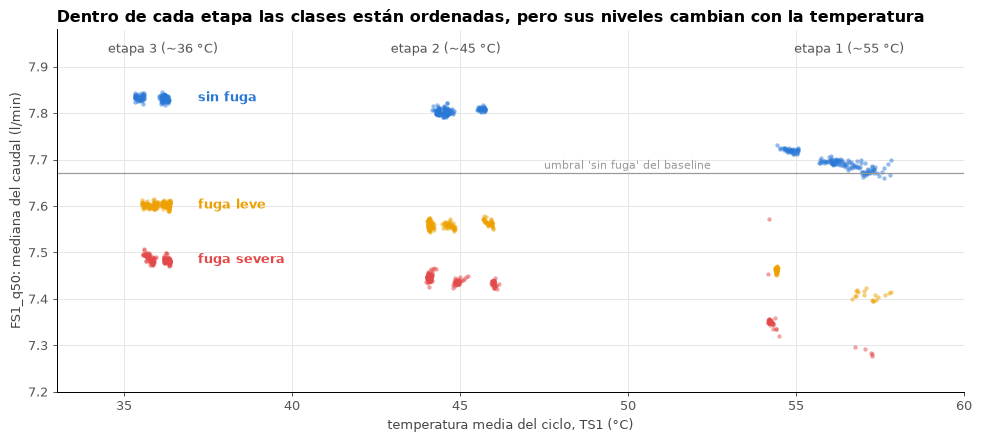

Ciclos estables fuera del gráfico (caudal < 7,2 l/min): 233, todos de la etapa 1: True


In [12]:
temp = X_todos["TS1_mean"].to_numpy()
caudal = X_fis["FS1_q50"].to_numpy()
estable = perfil["estable"].to_numpy() == 0

fig, ax = plt.subplots(figsize=(11, 5))
for c in CLASES:
    sel = (y == c) & estable
    ax.scatter(temp[sel], caudal[sel], s=12, alpha=0.5, color=COLOR_BOMBA[c], lw=0)
    # etiqueta de cada clase al lado de su nube en la etapa 3
    yc = np.median(caudal[sel & (etapa == 100)])
    ax.text(37.2, yc, NOMBRES_BOMBA[c], color=COLOR_BOMBA[c], fontweight="bold", va="center")
for valor, nombre in NOMBRE_ETAPA.items():
    ax.text(np.median(temp[(etapa == valor) & estable]), 7.93, nombre, ha="center",
            color="#555555", fontsize=10)
ax.axhline(umbral_alto, color=GRIS, lw=1)
ax.text(47.5, umbral_alto + 0.01, "umbral 'sin fuga' del baseline", color=GRIS, fontsize=9)
ax.set_ylim(7.2, 7.98)
ax.set_xlim(33, 60)
ax.set_xlabel("temperatura media del ciclo, TS1 (°C)")
ax.set_ylabel("FS1_q50: mediana del caudal (l/min)")
ax.set_title("Dentro de cada etapa las clases están ordenadas, pero sus niveles cambian con la temperatura")
plt.tight_layout()
plt.show()

fuera = (caudal < 7.2) & estable
print(f"Ciclos estables fuera del gráfico (caudal < 7,2 l/min): {fuera.sum()}, "
      f"todos de la etapa 1: {set(etapa[fuera]) == {3}}")

Cada nube de puntos es un estado de la bomba en una etapa (mostramos sólo los ciclos estables). Se ven dos cosas:

- **La temperatura corre todos los valores.** Dentro de cada etapa las tres clases están ordenadas (sin fuga arriba, fuga severa abajo), pero el nivel de cada una cambia de una etapa a otra. La línea gris es el umbral del baseline: en las etapas 2 y 3 deja a la bomba sana bien arriba, pero en la etapa 1 la bomba sana queda pegada a la línea, y algunos ciclos sanos ya caen debajo (serían falsas alarmas). Un umbral que separa bien en una etapa no sirve en otra.
- **En la etapa más caliente aparecen además ciclos muy raros**: 233 ciclos estables (casi todos con fuga y con el acumulador deteriorado) tienen un caudal tan bajo que quedan fuera del gráfico. Son los mismos ciclos en los que la eficiencia se desplomaba en la Parte I. Si el modelo nunca vio esa etapa, no tiene forma de saber qué hacer con ellos.

### 2.1 ¿Se puede corregir la temperatura?

Una idea razonable es "descontar" el efecto de la temperatura antes de entrenar. Lo probamos así: con los ciclos **sin fuga** del entrenamiento ajustamos, para cada feature, una recta que dice cuánto vale esa feature según la temperatura del ciclo. Después, a cada ciclo (de entrenamiento y de test) le restamos lo que la recta predice para su temperatura. Lo que queda es "cuánto se aparta este ciclo de una bomba sana a esa misma temperatura", que en teoría ya no depende de la temperatura. Las rectas se ajustan sólo con el entrenamiento, así que no hay fuga de información.

In [13]:
def corregir_temperatura(X_tr, T_tr, y_tr, X_te, T_te):
    # recta feature = a + b * temperatura, ajustada con los ciclos sin fuga del entrenamiento
    A_tr = np.column_stack([np.ones(len(T_tr)), T_tr])
    sanos = y_tr == 0
    coef, *_ = np.linalg.lstsq(A_tr[sanos], X_tr[sanos], rcond=None)
    A_te = np.column_stack([np.ones(len(T_te)), T_te])
    return X_tr - A_tr @ coef, X_te - A_te @ coef


sin_temperaturas = [c for c in X_fis.columns if not c.startswith("TS")]
XC = X_fis[sin_temperaturas].to_numpy()

filas = {}
for nombre in nombres_modelos:
    fila = {}
    for valor, nombre_etapa in NOMBRE_ETAPA.items():
        afuera = etapa == valor
        a, b = corregir_temperatura(XC[~afuera], temp[~afuera], y[~afuera], XC[afuera], temp[afuera])
        m = clone(modelos[nombre]).fit(a, y[~afuera])
        fila[nombre_etapa] = f1_score(y[afuera], m.predict(b), average="macro")
    filas[nombre] = fila
corregido = pd.DataFrame(filas).T

pd.DataFrame({"sin corregir (promedio)": sin_calc.mean(axis=1),
              "corrigiendo temperatura (promedio)": corregido.mean(axis=1)}).join(corregido).round(2)

,sin corregir (promedio),corrigiendo temperatura (promedio),etapa 1 (~55 °C),etapa 2 (~45 °C),etapa 3 (~36 °C)
KNN,0.42,0.47,0.36,0.52,0.53
SVM (RBF),0.55,0.49,0.24,1.00,0.24
SVM (lineal),0.76,0.61,0.28,0.92,0.63
Árbol de decisión,0.57,0.81,0.88,1.00,0.56
Random Forest,0.63,0.70,0.55,1.00,0.56
XGBoost,0.59,0.65,0.34,1.00,0.59


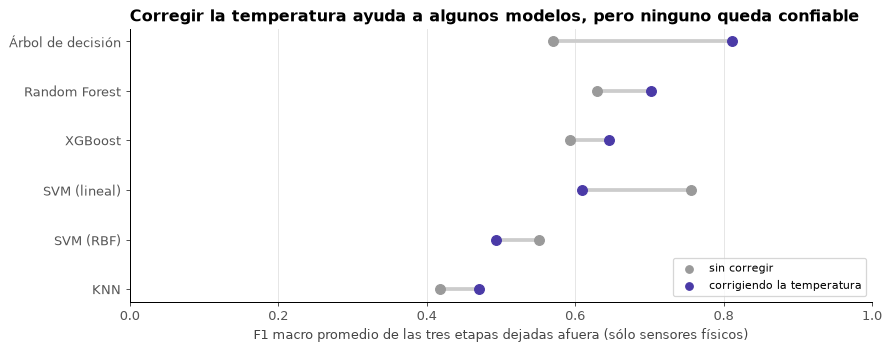

In [14]:
comparar = pd.DataFrame({"sin corregir": sin_calc.mean(axis=1),
                         "corrigiendo la temperatura": corregido.mean(axis=1)}).sort_values("corrigiendo la temperatura")
fig, ax = plt.subplots(figsize=(10, 4))
for i, (nombre, fila) in enumerate(comparar.iterrows()):
    ax.plot([fila["sin corregir"], fila["corrigiendo la temperatura"]], [i, i], color="#cccccc", lw=3, zorder=1)
    ax.scatter(fila["sin corregir"], i, color=GRIS, s=60, zorder=2)
    ax.scatter(fila["corrigiendo la temperatura"], i, color=VIOLETA, s=60, zorder=2)
ax.scatter([], [], color=GRIS, label="sin corregir")
ax.scatter([], [], color=VIOLETA, label="corrigiendo la temperatura")
ax.set_yticks(range(len(comparar)), comparar.index)
ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("F1 macro promedio de las tres etapas dejadas afuera (sólo sensores físicos)")
ax.legend(loc="lower right", fontsize=9)
ax.set_title("Corregir la temperatura ayuda a algunos modelos, pero ninguno queda confiable")
plt.tight_layout()
plt.show()

La corrección mejora a los modelos basados en árboles (sobre todo al árbol de decisión, que pasa de 0,57 a 0,81 de promedio) y empeora a las dos SVM. Aun en el mejor caso, el árbol sigue fallando con la etapa 3 (F1 de 0,56), así que no llegamos a un resultado que nos animaríamos a usar en una planta. Creemos que la razón es que **con sólo tres temperaturas no hay forma de aprender bien cómo afecta la temperatura**: cuando dejamos una etapa afuera, la recta se ajusta con dos puntos de temperatura. Además, la fuga misma depende de la temperatura (el aceite caliente es más fluido y se escapa más fácil por el orificio), así que no alcanza con correr los valores: también cambia cuánto se separan las clases.

Sobre la crítica 2, nuestra conclusión es que **tenía razón en el fondo**. La división por etapa de la Parte I no es una trampa, porque responde una pregunta válida (*¿funciona el modelo en las condiciones que conoce?*), pero no responde la otra pregunta importante (*¿funciona en condiciones nuevas?*), y la respuesta a esa segunda pregunta es que no.

## Epílogo

| Crítica | Qué hicimos | Qué concluimos |
|---|---|---|
| 1. SE es un sensor calculado | Repetimos todo sin SE, CE ni CP | Era un atajo, pero no hacía falta: sin él los modelos siguen detectando la fuga, y ahí sí le ganan claramente a la regla simple (0,84 → ~1). |
| 2. Dividir por etapa esconde el problema | Entrenamos con dos temperaturas y evaluamos con la tercera | Tenía razón. Con una temperatura intermedia los modelos funcionan, pero con la más caliente fallan todos y con la más fría sólo funcionan si usan SE. Corregir la temperatura no alcanza. |
| 3. Faltaban curvas ROC | Curvas ROC por clase para la SVM lineal | AUC ≈ 1 en las tres clases: el resultado no depende del umbral. |
| 4. Faltaban tramos y frecuencias | Probamos features por tramo de 10 s | Mejoran un poco la SVM lineal (0,89 → 0,91 en CV). El análisis de frecuencias no es posible con la frecuencia de muestreo de estos sensores. |

**Cómo cambia nuestra respuesta.** En la Parte I dijimos que la fuga de la bomba se puede detectar con un ciclo de sensores, y lo seguimos sosteniendo, con dos agregados:

1. No hace falta el sensor calculado `SE`: con caudal, presión y potencia del motor una SVM lineal llega al mismo nivel. Es un modelo un poco menos simple que el árbol de la Parte I, pero que no depende de un indicador armado de antemano. Eso sí, `SE` resultó tener una ventaja que no habíamos visto: aguanta mejor un cambio de temperatura hacia abajo, porque al ser una eficiencia ya compensa parte de ese efecto. Usar el sensor calculado no era hacer trampa, era aprovechar conocimiento físico que ya venía en los datos.
2. Todo eso vale **sólo para temperaturas de operación que estén representadas en el entrenamiento**. Si este sistema se usara en una planta, lo primero que recomendaríamos es juntar datos de la bomba sana y con fuga en todo el rango de temperaturas en que va a trabajar, antes de confiar en el modelo.

**Lo que aprendimos con esta segunda parte** es que someter el trabajo a una crítica dura sirvió más que seguir agregando modelos. Algunas objeciones no se sostuvieron cuando las probamos, y otra nos mostró el límite real de lo que hicimos, que en la Parte I no habíamos visto.

## Referencias

- Dataset: ZeMA gGmbH, *Condition monitoring of hydraulic systems*. UCI Machine Learning Repository (2018). Copia en Kaggle: https://www.kaggle.com/datasets/jjacostupa/condition-monitoring-of-hydraulic-systems
- N. Helwig, E. Pignanelli, A. Schütze. *Condition Monitoring of a Complex Hydraulic System Using Multivariate Statistics*. IEEE I2MTC 2015. doi: 10.1109/I2MTC.2015.7151267
- T. Schneider, N. Helwig, A. Schütze. *Automatic feature extraction and selection for classification of cyclical time series data*. tm - Technisches Messen 84(3), 2017. doi: 10.1515/teme-2016-0072
- Material de clase de Aprendizaje de Máquina I, CEIA - FIUBA.
- Documentación de scikit-learn (`permutation_importance`, `roc_curve`, `GroupKFold`) y XGBoost.